In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
"""
Initialize the analysis environment by loading essential modules and setting up
the Python path to access custom analysis functions.
"""

# Enable automatic reloading of modules for interactive development
%load_ext autoreload
%autoreload 2

# Import essential system modules
import sys
from pathlib import Path

# Define the path to custom analysis modules
# Note: Update this path to match your local installation
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

# Add module path to system path for importing custom functions
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")
print("🔄 Auto-reload enabled for interactive development")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis
🔄 Auto-reload enabled for interactive development


In [2]:
from nwb_utils import NWBUtils
from optogenetics_utils import create_opto_data_frame, find_unique_combinations,find_unique_stimulation,create_opto_data_frame_combined,load_opto_data_frame,find_unique_values_by_conditions

In [5]:
combined_dataframe=load_opto_data_frame(csv_path = '/root/capsule/scratch/combined_opto_data_frame.csv')

In [10]:

combined_dataframe_o=load_opto_data_frame(csv_path = '/root/capsule/scratch/combined_opto_data_frame.csv')

combined_dataframe=create_opto_data_frame_combined(save_path='/root/capsule/scratch/combined_opto_data_frame.csv',existing_data=combined_dataframe_o)

Skipping 110 NWB file(s) already present in existing_data.


Processing NWB files:   0%|          | 0/58 [00:00<?, ?file/s]

Found behavior NWB: /root/capsule/data/optogenetics_nwb/780284_2025-04-30_14-26-13.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/780284_2025-04-30_14-26-13.nwb
[Attempt 1/3] Network failure fetching fits for 780284_2025-04-30_14-26-13.json: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
No model-fitting results for subject 780284 on 2025-04-30
Error processing /root/capsule/data/optogenetics_nwb/780284_2025-04-30_14-26-13.nwb: Latent 'deltaQ' could not be extracted for model 'QLearning_L1F1_CK1_softmax'.
Found behavior NWB: /root/capsule/data/optogenetics_nwb/780284_2025-05-01_12-34-19.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/780284_2025-05-01_12-34-19.nwb
No model-fitting results for subject 780284 on 2025-05-01
Error processing /root/capsule/data/optogenetics_nwb/780284_2025-05-01_12-34-19.nwb: Latent 'deltaQ' could not be extracted for model 'QLearning_L1F1_CK1_softmax'.


In [6]:
import importlib
import optogenetics_utils

# reload the whole module
importlib.reload(optogenetics_utils)

# now re-import the updated function
from optogenetics_utils import find_unique_stimulation,normalize_string_columns

combined_dataframe=normalize_string_columns(combined_dataframe)
find_unique_stimulation(combined_dataframe,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation','laser_1_target_areas','laser_2_target_areas','laser_rampingdown'
    ])

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,...,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left MD inactivation,right MD inactivation,NaN,20445,50,7
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left ALM inactivation,right ALM inactivation,NaN,18835,48,6
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,NaN,NaN,NaN,10070,20,5
3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,NaN,9574,22,9
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,4906,12,3
5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,3357,8,3
6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,2297,6,3
7,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,off,0.5,on,on,left MD inactivation,right MD inactivation,0.20,1174,48,7
8,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left mPFC inactivation,right mPFC inactivation,NaN,794,2,1
9,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,off,0.5,on,on,left ALM inactivation,right ALM inactivation,0.20,690,44,6


In [22]:
conds = {"laser_start": "Go cue", "laser_end": "Trial start"}
unique_vals = find_unique_values_by_conditions(combined_dataframe, conds, output_column="session")
print(unique_vals)

[]


In [23]:
nwb_path="/root/capsule/data/optogenetics_nwb/789197_2025-08-05_10-49-42.nwb"

nwb_data=NWBUtils.read_behavior_nwb(nwb_full_path=nwb_path)

Found behavior NWB: /root/capsule/data/optogenetics_nwb/789197_2025-08-05_10-49-42.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/789197_2025-08-05_10-49-42.nwb


In [17]:
import pandas as pd
conditions=find_unique_stimulation(combined_dataframe,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation','laser_1_target_areas','laser_2_target_areas','laser_rampingdown'
    ])

conditions=find_unique_stimulation(combined_dataframe,columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',   'laser_duration', 'laser_start',
        'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency',  'laser_pulse_duration',
        'laser_1_target_areas','laser_2_target_areas','laser_rampingdown'
    ])





conditions = conditions.sort_values(
    by=["laser_1_target_areas", "laser_2_target_areas","n_trials","laser_start"], 
    ascending=[True, False,False,False]  # True=ascending, False=descending
)

# pick a row (e.g., the most frequent combo)
row = conditions.loc[13]

# turn it into a criteria dict
criteria = (
    row.drop(labels=['n_trials','n_session','n_mice'], errors='ignore')
       .where(pd.notna(row), None)         # pd.NA/NaN -> None
       .to_dict()
)

criteria


{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 1.0,
 'laser_start': 'trial start',
 'laser_start_offset': 0.0,
 'laser_end': None,
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'laser_1_target_areas': 'left MD inactivation',
 'laser_2_target_areas': 'right MD inactivation',
 'laser_rampingdown': 0.2}

In [8]:
conditions

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,laser_pulse_duration,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left ALM inactivation,right ALM inactivation,NaN,18835,48,6
7,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,690,44,6
8,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,571,37,6
10,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,556,36,5
11,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,514,37,5
26,1,473.0,both,3.0,go cue,0.0,trial start,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,123,7,1
27,1,473.0,both,3.0,go cue,0.3,trial start,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.20,120,7,1
30,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,1.00,49,4,2
32,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.02,43,3,1
33,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,0.002,left ALM inactivation,right ALM inactivation,0.02,39,3,1


In [13]:
criteria={'laser_on_trial': '1',
 'laser_wavelength': '473.0',
 'laser_location': 'Both',
 'laser_duration': '50.0',
 'laser_start': 'Trial start',
 'laser_start_offset': '0.0',
 'laser_end': 'Go cue',
 'laser_end_offset': '0.0',
 'laser_protocol': 'Sine',
 'laser_frequency': '20.0',
 'laser_pulse_duration': '0.002',
 'session_wide_control': 'off',
 'fraction_of_session': '0.5',
 'session_start_with': 'on',
 'session_alternation': 'on',
 "session":"795396_2025-09-20_13-11-19"}

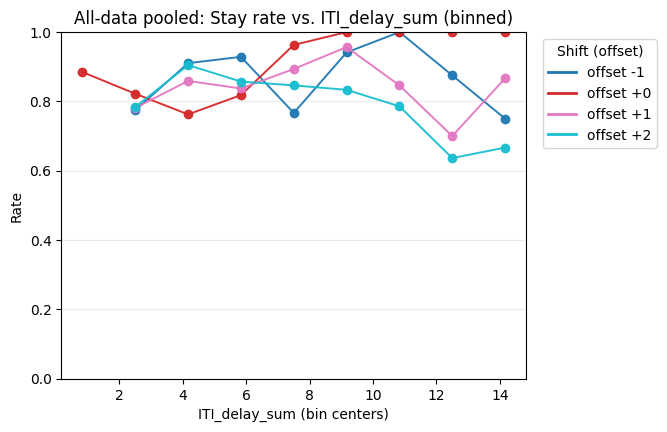

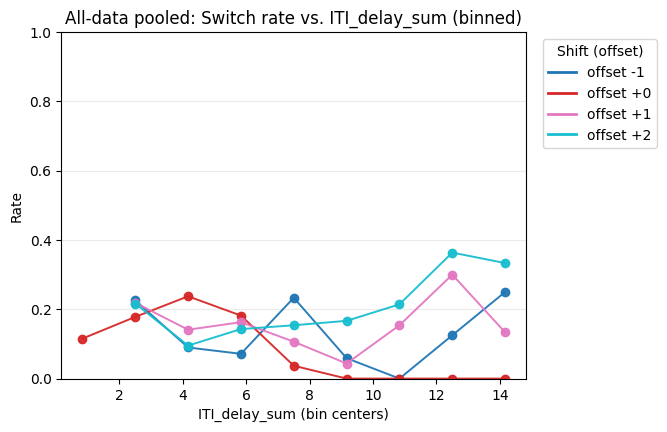

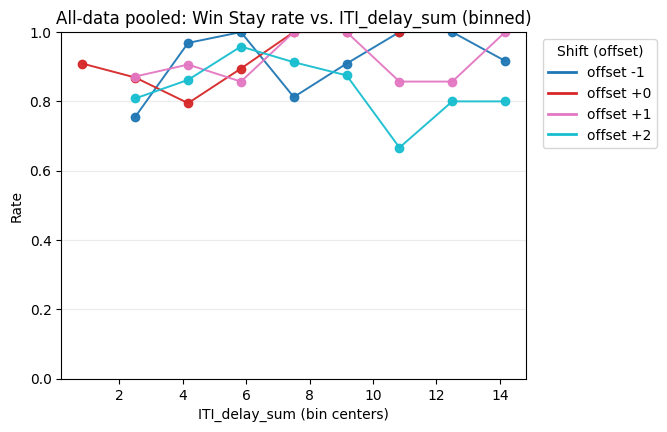

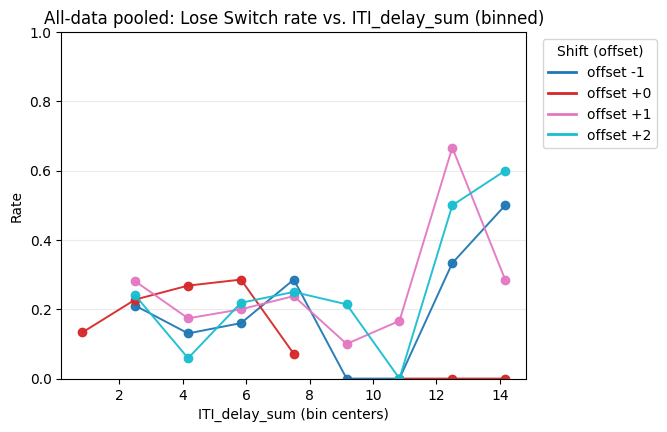

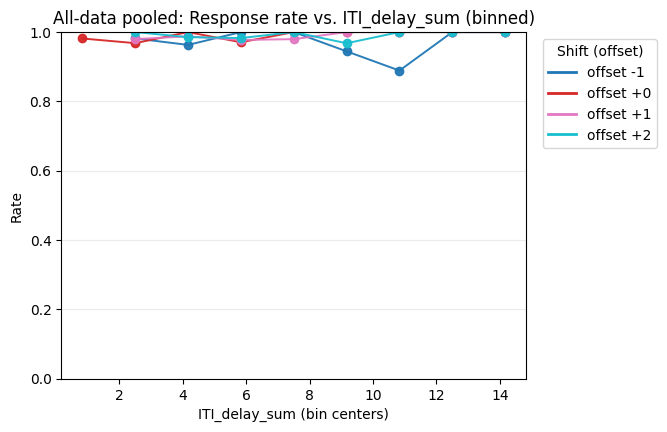

In [18]:
from optogenetics_visualization import plot_rates_vs_latent
figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="ITI_delay_sum",
    line_by="all",
    bins=9,
    binning="uniform",
    criteria = criteria,
    latent_range=(0,15),
    window=[-1,2],
)

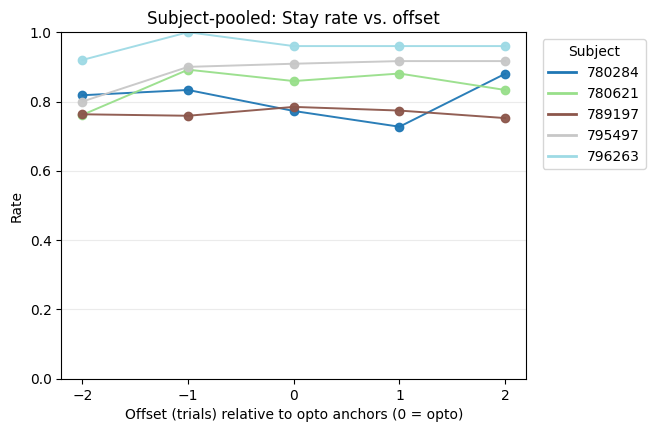

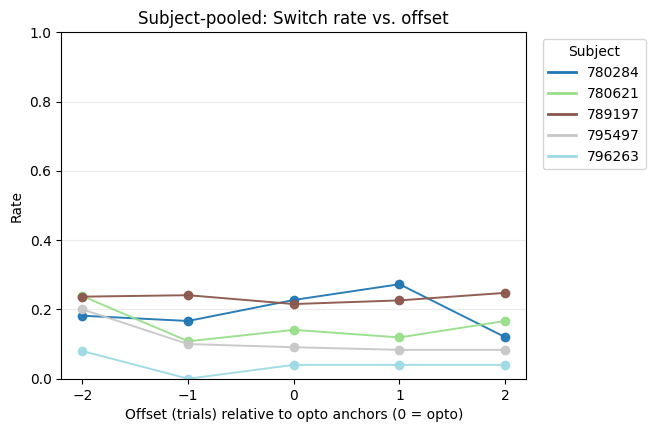

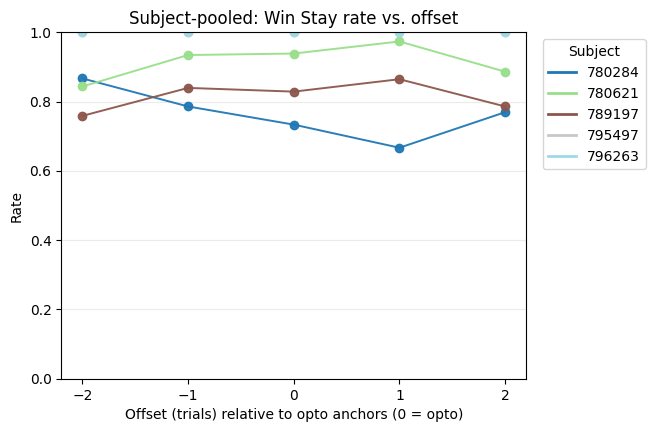

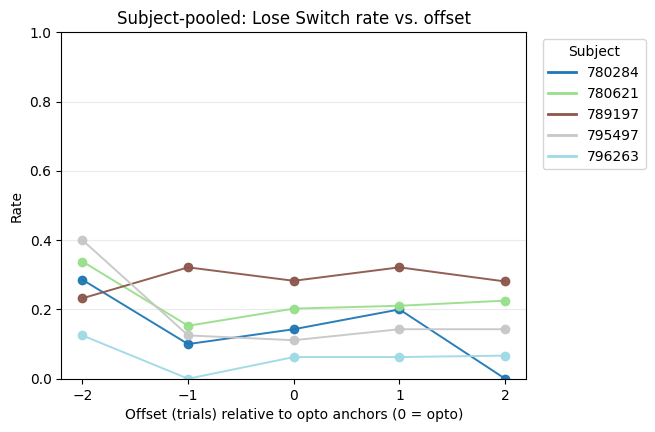

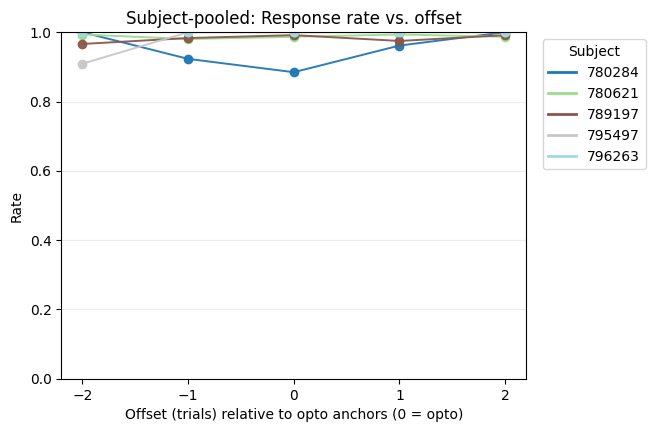

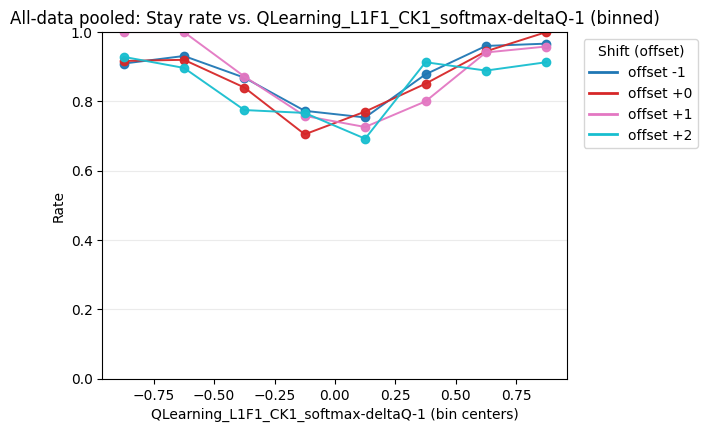

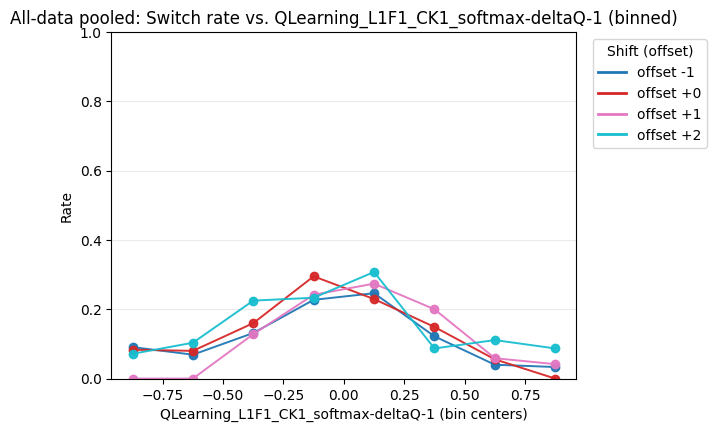

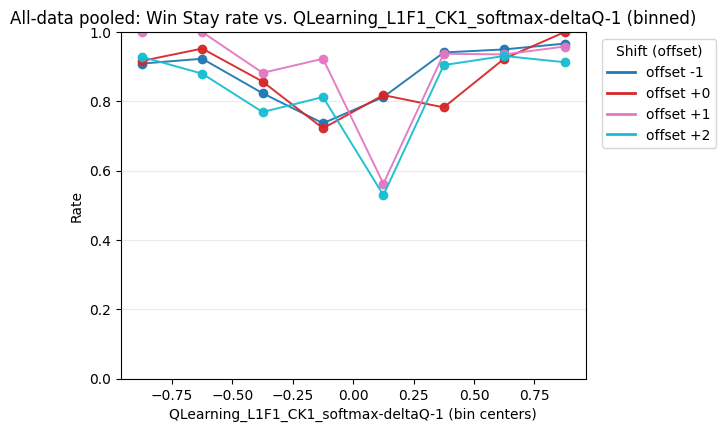

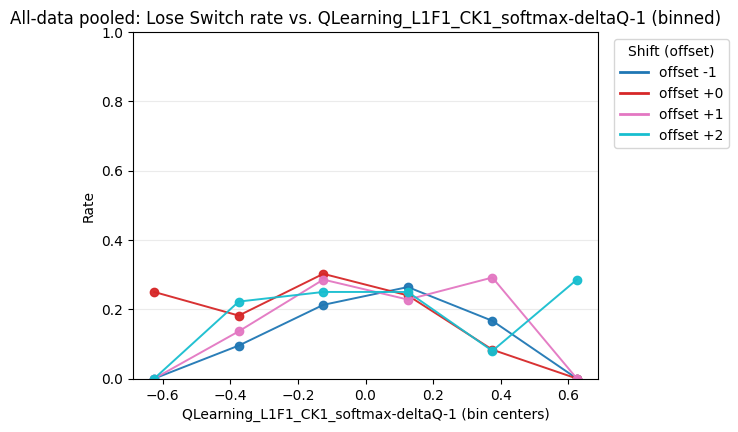

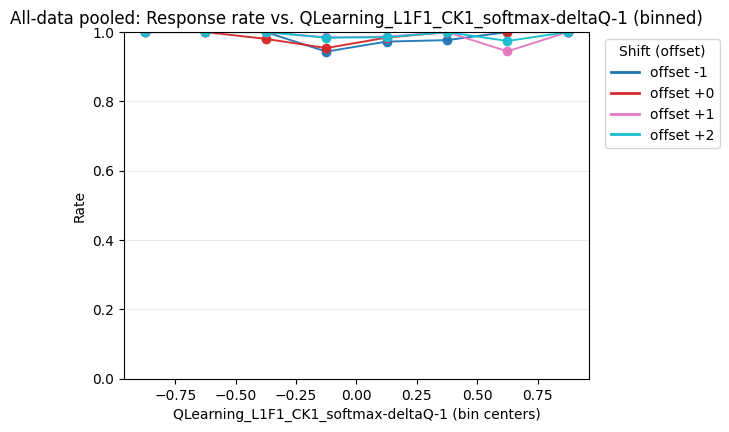

In [19]:
# visualization
from nwb_utils import NWBUtils
from optogenetics_utils import create_opto_data_frame, find_unique_combinations,find_unique_stimulation,create_opto_data_frame_combined,load_opto_data_frame,find_unique_values_by_conditions
from optogenetics_visualization import plot_stay_switch_over_window, plot_rates_vs_latent
#combined_dataframe=load_opto_data_frame(csv_path = '/root/capsule/scratch/combined_opto_data_frame.csv')
plot_stay_switch_over_window(combined_dataframe,criteria = criteria,window=[-2,2],line_by='subject')


figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="QLearning_L1F1_CK1_softmax-deltaQ-1",
    line_by="all",
    bins=8,
    binning="uniform",
    criteria = criteria,
    window=[-1,2]
)
